|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 0:</h2>|<h1>From a Program to a Model<h1>|
|<h2>Section:</h2>|<h1>The model<h1>|
|<h2>Lecture:</h2>|<h1><b>The generation loop<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
# Find the repo root. The directory you start from does not matter.
import sys
from pathlib import Path
ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# The notebook runs on a GPU if there is one, and on the CPU if not.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE = torch.bfloat16 if DEVICE == 'cuda' else torch.float32
MODEL_NAME = 'Qwen/Qwen3-0.6B'

/home/venugopalan/vllm-from-scratch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# One token at a time

The model predicts ONE next token. A reply has hundreds. So you call the model
in a loop: predict one token, append it to the input, and call the model
again. This loop is **autoregressive generation**. Each new token depends on
all the tokens before it. The prompt and the tokens that the loop adds are one
**sequence**.

This notebook writes the loop, and then counts what the loop costs.

In [2]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=DTYPE).to(DEVICE).eval()
print(f'{MODEL_NAME} on {DEVICE}')

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 11875.28it/s]

Qwen/Qwen3-0.6B on cuda


### The simplest loop

Choose the token with the highest logit at each step. This rule is **greedy
decoding**. `argmax` finds that token.

In [3]:
prompt = 'The three most important ideas in computer science are'
token_ids = tokenizer(prompt).input_ids

with torch.no_grad():
  for _ in range(20):
    logits = model(torch.tensor([token_ids], device=DEVICE)).logits
    next_token = int(logits[0, -1].argmax())    # greedy: the highest score
    token_ids.append(next_token)

print(tokenizer.decode(token_ids))

The three most important ideas in computer science are algorithms, data structures, and software engineering. These three are the foundation of computer science. The question


That is all of text generation. The library method `generate` runs the same
loop. Check that the two agree.

`use_cache=False` makes the library do the same work as your loop. The
`attention/` section explains the cache, and why it changes the last digits
of the arithmetic.

In [4]:
prompt_ids = tokenizer(prompt, return_tensors='pt').input_ids.to(DEVICE)
with torch.no_grad():
  library_ids = model.generate(prompt_ids, max_new_tokens=20, do_sample=False,
                               use_cache=False)[0].tolist()
print('your loop and generate() agree:', library_ids == token_ids)

your loop and generate() agree: True


### The reply must stop

The model has a special token, **EOS**, "end of sequence". When the model
makes it, the reply is complete. Your loop must stop there, or it continues
with text that nobody asked for.

A chat model makes EOS at the end of its turn in a chat. So the prompt must use
the chat format, with a marker for each role. `apply_chat_template` builds
that format.

In [5]:
eos_id = tokenizer.eos_token_id
print(f'EOS is token {eos_id}: {tokenizer.decode([eos_id])!r}')

def generate_greedy(prompt, max_new_tokens):
  """Greedy decoding that stops at EOS. -> the new text."""
  token_ids = tokenizer(prompt).input_ids
  new_ids = []
  with torch.no_grad():
    for _ in range(max_new_tokens):
      logits = model(torch.tensor([token_ids + new_ids], device=DEVICE)).logits
      next_token = int(logits[0, -1].argmax())
      if next_token == eos_id:
        break
      new_ids.append(next_token)
  return tokenizer.decode(new_ids)

chat_prompt = tokenizer.apply_chat_template(
    [{'role': 'user', 'content': 'What is 2 + 2? Answer in one short sentence.'}],
    tokenize=False, add_generation_prompt=True, enable_thinking=False)
print(repr(chat_prompt))
print(repr(generate_greedy(chat_prompt, max_new_tokens=40)))

EOS is token 151645: '<|im_end|>'
'<|im_start|>user\nWhat is 2 + 2? Answer in one short sentence.<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n'
'2 + 2 = 4.'


### Choose at random

Greedy decoding gives the same text each time. A chat model usually chooses at
random, with the probabilities that softmax gives. This is **sampling**.

**Temperature** controls how random the choice is. Divide the logits by it
before softmax. A temperature below 1 makes the high scores higher, so the
choice is safer. A temperature above 1 makes the scores more equal, so the
choice is more random.

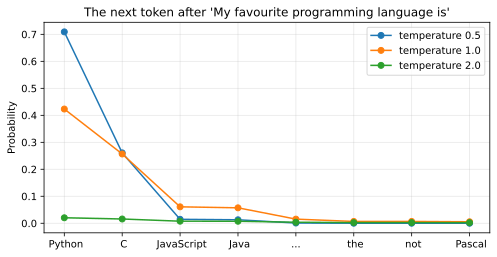

In [6]:
prompt = 'My favourite programming language is'
with torch.no_grad():
  last_row = model(torch.tensor([tokenizer(prompt).input_ids], device=DEVICE)).logits[0, -1].float()

top_ids = torch.topk(last_row, 8).indices
labels = [tokenizer.decode([token_id]) for token_id in top_ids]
plt.figure(figsize=(8, 3.8))
for temperature in (0.5, 1.0, 2.0):
  probs = torch.softmax(last_row / temperature, -1)[top_ids].cpu()
  plt.plot(labels, probs, 'o-', label=f'temperature {temperature}')
plt.ylabel('Probability')
plt.title(f'The next token after {prompt!r}')
plt.legend()
plt.grid(alpha=.3)
plt.show()

In [7]:
generator = torch.Generator(device=DEVICE).manual_seed(0)
for _ in range(4):
  probs = torch.softmax(last_row / 0.8, -1)
  choice = int(torch.multinomial(probs, 1, generator=generator))
  print(f'{prompt}{tokenizer.decode([choice])!r}')

My favourite programming language is' Python'
My favourite programming language is' Python'
My favourite programming language is' Java'
My favourite programming language is' C'


### Count the work

Look again at the loop. Each call gives the model the FULL text: the prompt
and all the tokens so far. So each step processes one token more than the step
before it.

The first call processes the whole prompt. Its name is **prefill**. Each later
call adds one token. Its name is **decode**. In this loop, a decode call does
the work of all the earlier tokens again. Count the tokens that the model
processes.

In [8]:
PROMPT_TOKENS = 200
NEW_TOKENS = 200
processed = [PROMPT_TOKENS + step for step in range(NEW_TOKENS)]
print(f'tokens that the reply needs:          {NEW_TOKENS}')
print(f'tokens that the model processes:      {sum(processed):,}')
print(f'work for each useful token, on average: {sum(processed)/NEW_TOKENS:.0f} tokens')

tokens that the reply needs:          200
tokens that the model processes:      59,900
work for each useful token, on average: 300 tokens


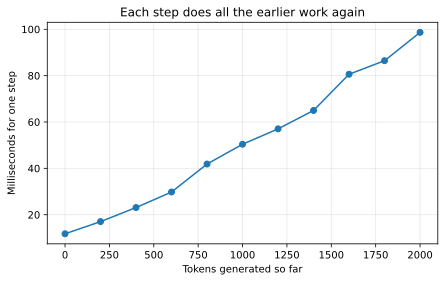

In [9]:
# Now measure it. The time of each step grows with the length of the text.
prompt_ids = torch.randint(0, 1000, (PROMPT_TOKENS,)).tolist()
step_ms = []
with torch.no_grad():
  for step in range(0, 2001, 200):
    input_ids = torch.tensor([prompt_ids + [0] * step], device=DEVICE)
    model(input_ids)                                        # warm up
    if DEVICE == 'cuda':
      torch.cuda.synchronize()
    start = time.perf_counter()
    model(input_ids)
    if DEVICE == 'cuda':
      torch.cuda.synchronize()
    step_ms.append((step, 1000 * (time.perf_counter() - start)))

steps, times = zip(*step_ms)
plt.figure(figsize=(7, 4))
plt.plot(steps, times, 'o-')
plt.xlabel('Tokens generated so far')
plt.ylabel('Milliseconds for one step')
plt.title('Each step does all the earlier work again')
plt.grid(alpha=.3)
plt.show()

The line can be almost flat at the start. A GPU has spare capacity for a short
text, so a few more tokens cost almost nothing. Part 4 measures where that
stops. After that point, each step costs more than the step before it.

### What to remember from this notebook

- Text generation is a loop: call the model, choose one token, append it.
- **Greedy decoding** chooses the highest score. **Sampling** chooses at
  random, and **temperature** sets how random.
- The loop stops at **EOS**, or at a length limit.
- **Prefill** is the first call, over the whole prompt. Each **decode** call
  adds one token.
- This loop does all the earlier work again at each step. The total work
  grows with the square of the length.

The part of the work that repeats has a name: the keys and values of
attention. The `attention/` section shows what they are, and how a cache
removes the repeated work. The challenge of this section comes first.